# 🚢 Titanic Dataset Visualization and Analysis using Seaborn

**Author:** Data Science Assignment  
**Dataset:** Titanic Dataset (CSV)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## 1. Introduction

### What is the Titanic Dataset?

The **Titanic dataset** contains information about the passengers aboard the RMS Titanic, which sank on April 15, 1912 after colliding with an iceberg. Out of 2,224 passengers and crew, more than 1,500 perished — making it one of the deadliest peacetime maritime disasters in history.

### Why is it Commonly Used?

The Titanic dataset is one of the most popular datasets in data science and machine learning because:
- It contains a **mix of numerical and categorical features**, making it ideal for both analysis and modeling.
- It presents a **binary classification problem** (survived or not), perfect for beginners.
- It contains **real-world data quality issues** like missing values, requiring preprocessing.
- It tells a compelling human story, making insights more meaningful.

### What Insights Do We Want to Explore?

- How did **gender** affect survival chances?
- Did **passenger class** (wealth) influence survival?
- What was the **age distribution** of passengers?
- Is there a relationship between **fare paid** and survival?
- How do various features **correlate** with each other?

### Dataset Column Descriptions

| Column | Description |
|---|---|
| **PassengerId** | Unique identifier for each passenger |
| **Survived** | Survival status (0 = No, 1 = Yes) |
| **Pclass** | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| **Name** | Passenger's full name |
| **Sex** | Passenger's gender |
| **Age** | Passenger's age in years |
| **SibSp** | Number of siblings/spouses aboard |
| **Parch** | Number of parents/children aboard |
| **Ticket** | Ticket number |
| **Fare** | Ticket fare paid (in British pounds) |

---

## 2. Import Libraries

We import all the required libraries for data loading, manipulation, and visualization. We use `sns.set()` to apply Seaborn's default theme for clean, professional-looking plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Apply Seaborn default theme
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

print(f"NumPy version    : {np.__version__}")
print(f"Pandas version   : {pd.__version__}")
print(f"Seaborn version  : {sns.__version__}")
print("Libraries imported successfully! ")

NumPy version    : 2.3.5
Pandas version   : 2.3.3
Seaborn version  : 0.13.2
Libraries imported successfully! 


---

## 3. Load the Dataset

We load the Titanic dataset from the provided CSV file using Pandas. After loading, we inspect the first few rows, the shape, column names, and data types to get an initial understanding of the data.

In [2]:
# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

print("=" * 55)
print("First 5 Rows:")
print("=" * 55)
print(df.head())

print(f"\nDataset Shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")

print("\n" + "=" * 55)
print("Data Types:")
print("=" * 55)
print(df.dtypes)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

---

## 4. Data Cleaning

Before visualizing, we must ensure the data is clean and reliable. We perform the following checks:

- **Missing values** — columns with nulls can distort analysis and must be handled
- **Duplicate rows** — duplicates may artificially inflate counts or statistics
- **Summary statistics** — gives us a quick overview of the range, mean, and spread of numerical columns

We fill missing **Age** values with the median (robust to outliers) and drop the **Cabin** column due to excessive missing data.

In [3]:
print("=" * 55)
print("Missing Values per Column:")
print("=" * 55)
print(df.isnull().sum())

print(f"\nDuplicate Rows : {df.duplicated().sum()}")

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)  # Too many missing values

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\n" + "=" * 55)
print("Summary Statistics:")
print("=" * 55)
print(df.describe().round(2))

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows : 0

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Summary Statistics:
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  891.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.36    0.52    0.38   32.20
std         257.35      0.49    0.84   13.02    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   22.00    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00 

---

## 5. Exploratory Data Analysis (EDA)

Our EDA focuses on three core goals:

1. **Passenger Demographics** — Understanding the age, gender, and class distribution of passengers
2. **Survival Patterns** — Identifying which groups of passengers were more likely to survive
3. **Feature Relationships** — Discovering correlations and dependencies between variables

We will use a wide variety of Seaborn plots to answer these questions.

In [ ]:
print("Survival Value Counts:")
print(df['Survived'].value_counts().rename({0: 'Did Not Survive', 1: 'Survived'}))

print("\nGender Distribution:")
print(df['Sex'].value_counts())

print("\nPassenger Class Distribution:")
print(df['Pclass'].value_counts().sort_index())

---

## Visualization 1 — Age Distribution Histogram

A histogram reveals the **age distribution** of all Titanic passengers. We can identify the most common age groups and check if the distribution is skewed. The KDE (Kernel Density Estimate) curve overlaid on the histogram shows the smooth probability distribution.

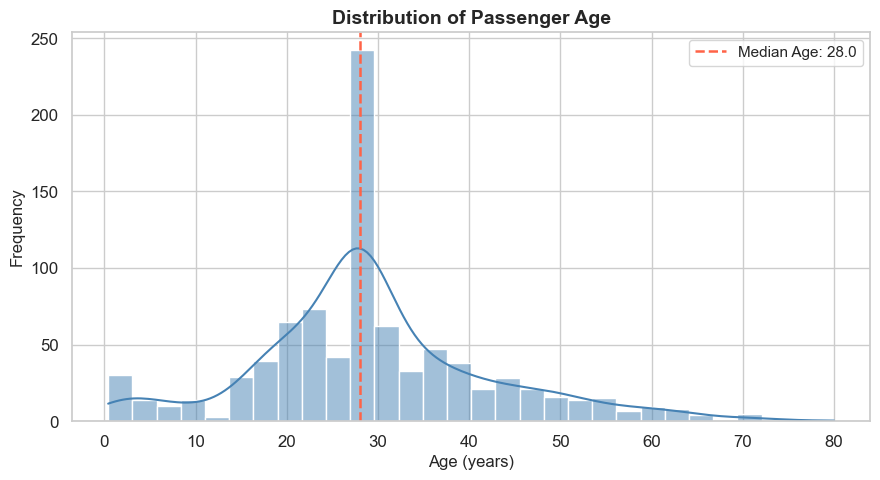

Saved: titanic_age_histogram.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df['Age'], bins=30, kde=True, color='steelblue', ax=ax)

ax.set_title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(df['Age'].median(), color='tomato', linestyle='--', linewidth=1.8, label=f'Median Age: {df["Age"].median():.1f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('titanic_age_histogram.png', dpi=150)
plt.show()
print("Saved: titanic_age_histogram.png")

---

## Visualization 2 — Bar Plot: Mean Age by Gender with Error Bars

This bar plot compares the **mean age of male vs female passengers**, with error bars showing the standard deviation. This helps us understand if age profiles differed significantly between genders.

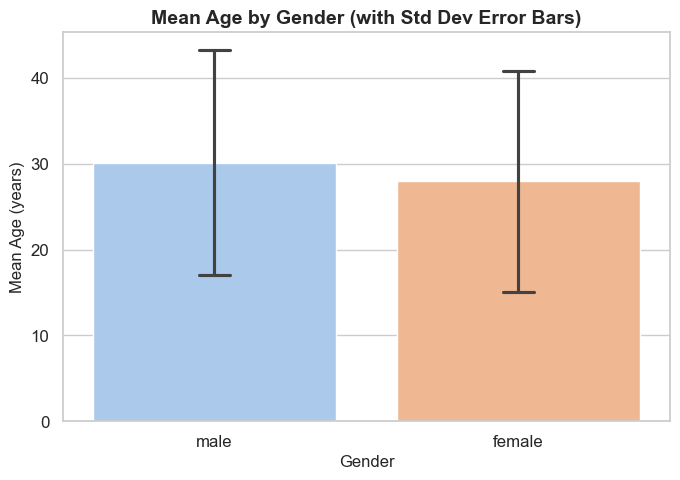

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(data=df, x='Sex', y='Age', palette='pastel',
            errorbar='sd', capsize=0.1, ax=ax)

ax.set_title('Mean Age by Gender (with Std Dev Error Bars)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Mean Age (years)', fontsize=12)

plt.tight_layout()
plt.show()

---

## Visualization 3 — Count Plot: Passengers per Ticket Class

This count plot shows **how many passengers were in each ticket class** (1st, 2nd, 3rd). Ticket class is a proxy for socioeconomic status and may have strongly influenced survival chances.

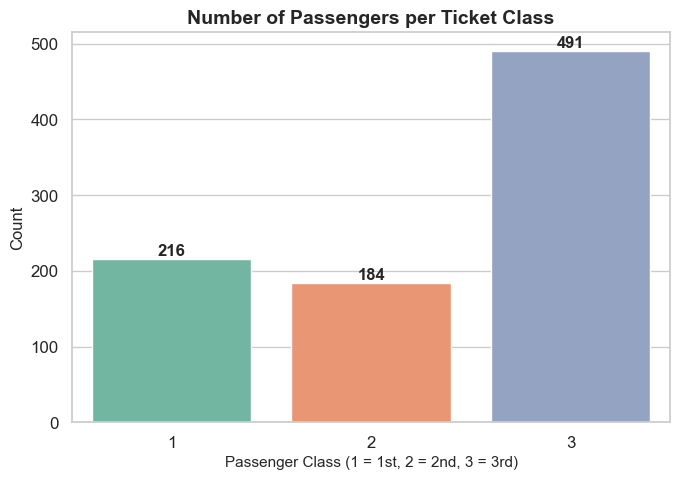

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(data=df, x='Pclass', palette='Set2', ax=ax)

ax.set_title('Number of Passengers per Ticket Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=11)
ax.set_ylabel('Count', fontsize=12)

# Annotate bars with counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Visualization 4 — Joint Plot: Age vs Fare

A joint plot combines a **scatter plot** with **marginal histograms/KDE plots** along both axes. Here we explore the relationship between a passenger's age and the fare they paid, which can reveal if older passengers tended to pay higher fares (suggesting higher class travel).

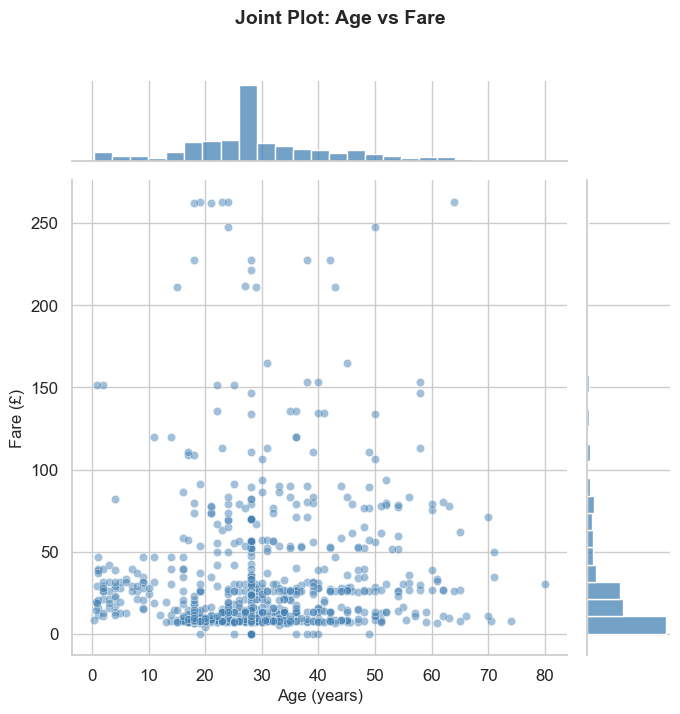

In [7]:
# Limit Fare to remove extreme outliers for better visualization
df_filtered = df[df['Fare'] < 300]

g = sns.jointplot(data=df_filtered, x='Age', y='Fare',
                  kind='scatter', color='steelblue',
                  marginal_kws=dict(bins=25, fill=True),
                  height=7, alpha=0.5)

g.figure.suptitle('Joint Plot: Age vs Fare', fontsize=14,
                   fontweight='bold', y=1.02)
g.set_axis_labels('Age (years)', 'Fare (£)', fontsize=12)

plt.tight_layout()
plt.show()

---

## Visualization 5 — Box Plot: Fare vs Survival

A box plot summarizes the **distribution of fares** for survivors vs non-survivors. The median, quartiles, and outliers are all visible. This helps answer whether passengers who paid more were more likely to survive (possibly due to access to lifeboats from upper decks).

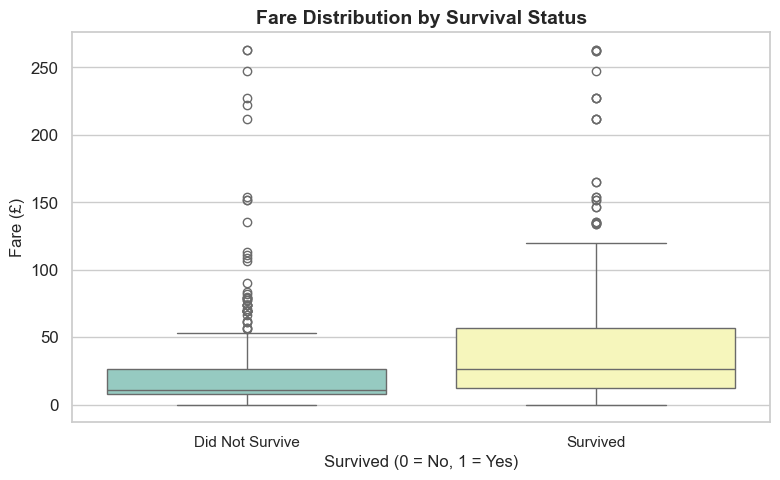

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df[df['Fare'] < 300], x='Survived', y='Fare',
            palette='Set3', ax=ax)

ax.set_title('Fare Distribution by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Did Not Survive', 'Survived'], fontsize=11)

plt.tight_layout()
plt.show()

---

## Visualization 6 — Heatmap: Feature Correlation

A heatmap shows the **pairwise correlation** between all numerical features. Values close to **+1** indicate strong positive correlation, close to **-1** indicate strong negative correlation, and near **0** indicate little relationship.

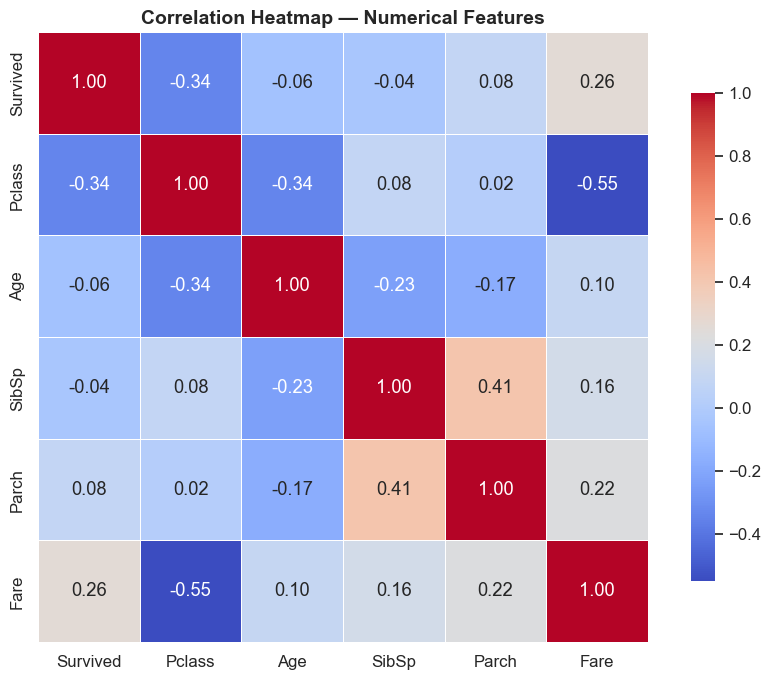

Saved: titanic_heatmap.png


In [9]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['PassengerId'])
corr_matrix  = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('titanic_heatmap.png', dpi=150)
plt.show()
print("Saved: titanic_heatmap.png")

---

## Visualization 7 — FacetGrid: Survival Distribution

A FacetGrid creates **multiple subplots** based on categorical variables. Here we visualize the distribution of the `Survived` attribute faceted by `Sex` (columns) and `Pclass` (rows), giving a breakdown of survival across all combinations of gender and class.

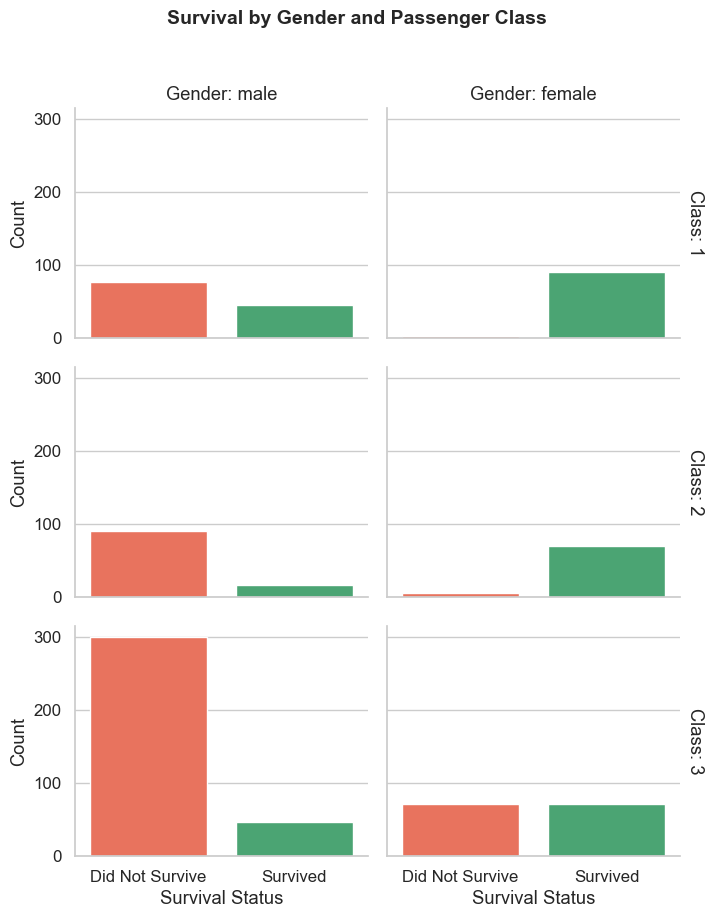

In [10]:
df['Survived_Label'] = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

g = sns.FacetGrid(df, col='Sex', row='Pclass',
                  height=3, aspect=1.2,
                  palette='Set2', margin_titles=True)

g.map_dataframe(sns.countplot, x='Survived_Label',
                palette=['tomato', 'mediumseagreen'],
                order=['Did Not Survive', 'Survived'])

g.set_axis_labels('Survival Status', 'Count')
g.set_titles(col_template='Gender: {col_name}', row_template='Class: {row_name}')
g.figure.suptitle('Survival by Gender and Passenger Class', fontsize=14,
                   fontweight='bold', y=1.02)
g.add_legend()

plt.tight_layout()
plt.show()

---

## Visualization 8 — Pair Plot

A pair plot generates **scatter plots for every pair of numerical features**, with histograms along the diagonal. Points are colored by survival status, making it easy to see which feature combinations best separate survivors from non-survivors.

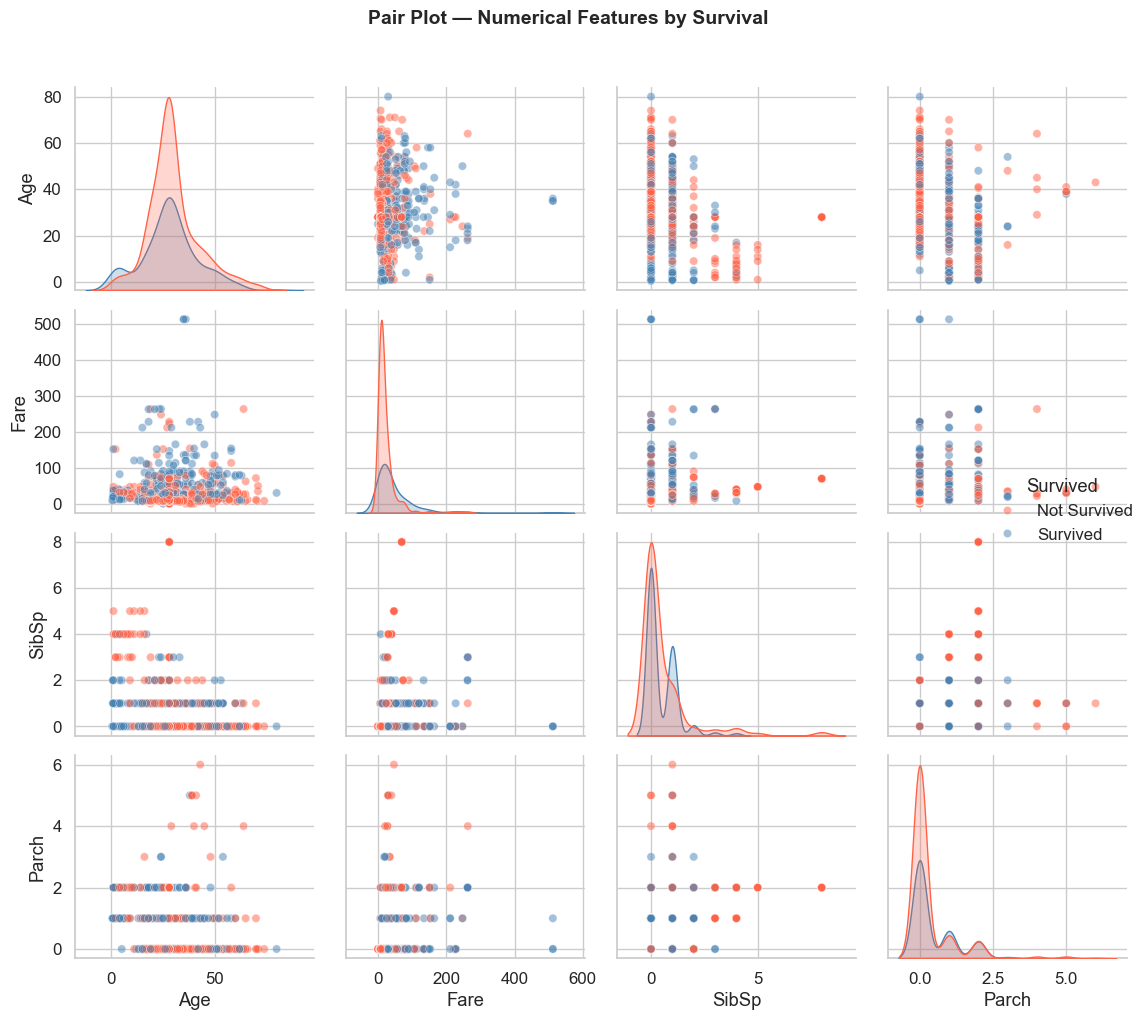

In [11]:
pair_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived']
df_pair   = df[pair_cols].copy()
df_pair['Survived'] = df_pair['Survived'].map({0: 'Not Survived', 1: 'Survived'})

g = sns.pairplot(df_pair, hue='Survived',
                 palette={'Not Survived': 'tomato', 'Survived': 'steelblue'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})

g.figure.suptitle('Pair Plot — Numerical Features by Survival',
                   fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

---

## Visualization 9 — Survival Count Plot

A simple count plot that shows the total number of passengers who **survived vs did not survive**. This is the fundamental outcome we are trying to understand throughout this analysis.

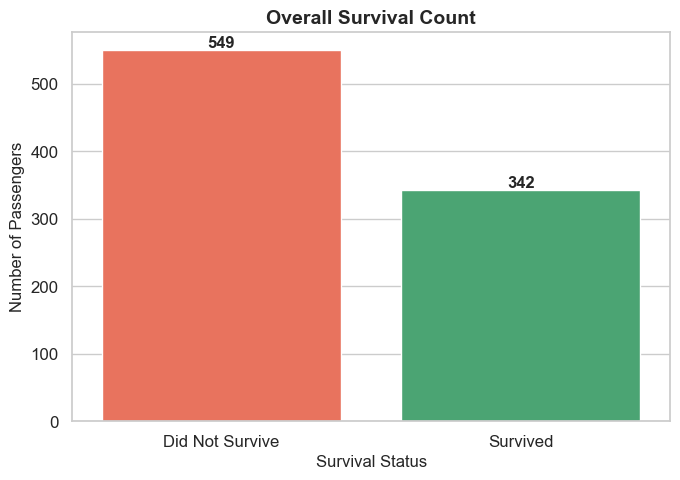

Saved: titanic_survival_plot.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(data=df, x='Survived_Label',
              palette=['tomato', 'mediumseagreen'],
              order=['Did Not Survive', 'Survived'], ax=ax)

ax.set_title('Overall Survival Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Survival Status', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('titanic_survival_plot.png', dpi=150)
plt.show()
print("Saved: titanic_survival_plot.png")

---

## Visualization 10 — Survival by Gender

This count plot compares survival between **male and female** passengers. The famous "women and children first" evacuation policy is expected to be clearly visible here.

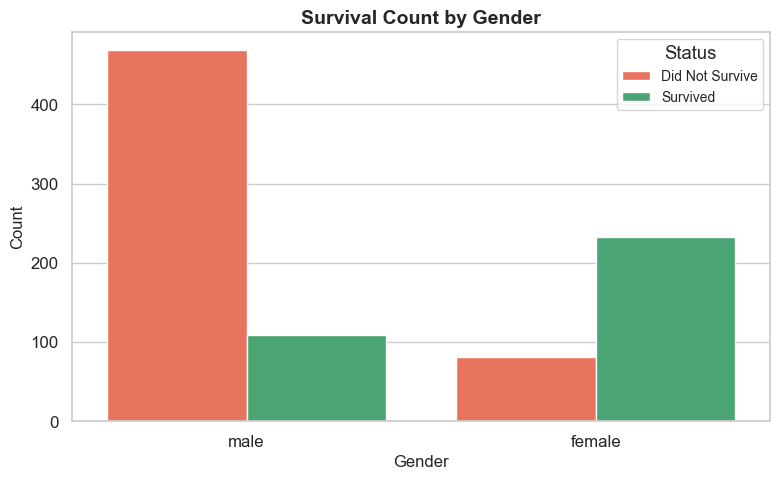

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x='Sex', hue='Survived_Label',
              palette={'Did Not Survive': 'tomato', 'Survived': 'mediumseagreen'},
              ax=ax)

ax.set_title('Survival Count by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Status', fontsize=10)

plt.tight_layout()
plt.show()

---

## Visualization 11 — Survival by Passenger Class

This plot reveals how **ticket class affected survival rates**. 1st class passengers had greater access to lifeboats (located on upper decks), while 3rd class passengers faced structural disadvantages in evacuation.

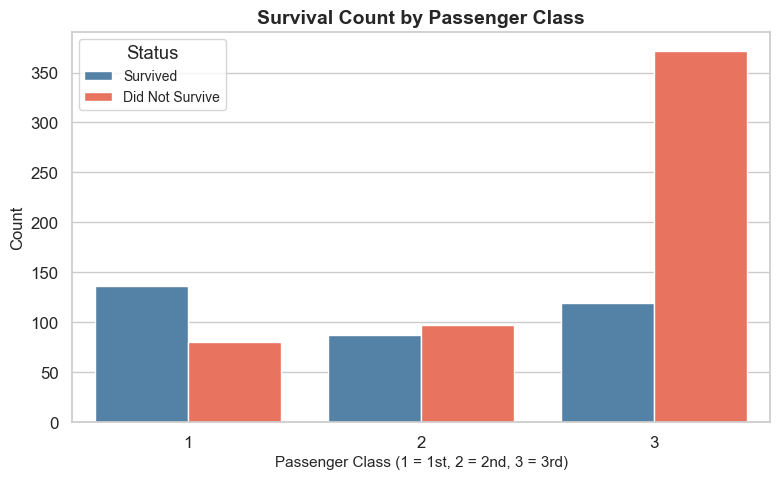

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x='Pclass', hue='Survived_Label',
              palette={'Did Not Survive': 'tomato', 'Survived': 'steelblue'},
              ax=ax)

ax.set_title('Survival Count by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=11)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Status', fontsize=10)

plt.tight_layout()
plt.show()

---

## Visualization 12 — Age Distribution by Gender (KDE Plot)

A **KDE (Kernel Density Estimate)** plot smoothly visualizes the age distribution for male and female passengers separately. This allows direct comparison of age profiles between genders.

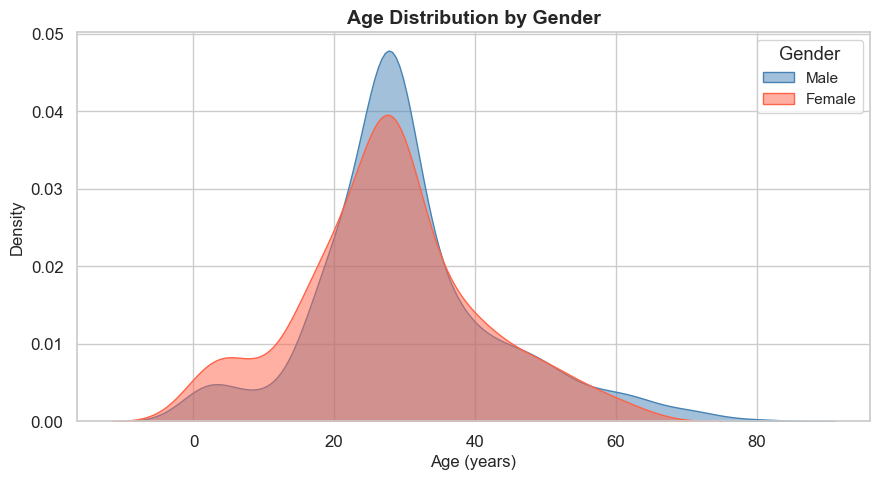

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(data=df[df['Sex'] == 'male'],   x='Age', label='Male',
            fill=True, color='steelblue', alpha=0.5, ax=ax)
sns.kdeplot(data=df[df['Sex'] == 'female'], x='Age', label='Female',
            fill=True, color='tomato', alpha=0.5, ax=ax)

ax.set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title='Gender', fontsize=11)

plt.tight_layout()
plt.show()

---

## Visualization 13 — Fare Distribution Histogram

The distribution of **ticket fares** is highly right-skewed — most passengers paid a modest fare, but a small number paid extremely high fares for luxury accommodations. The KDE overlay highlights this skewness.

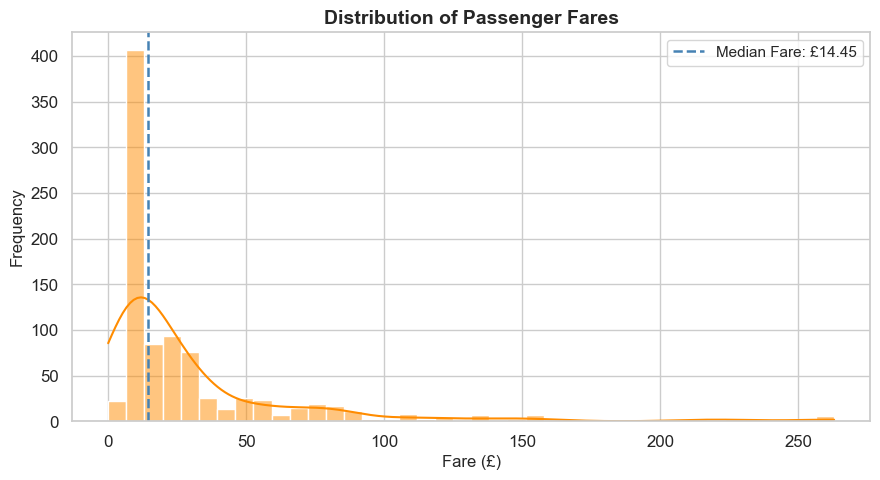

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df[df['Fare'] < 300]['Fare'], bins=40, kde=True,
             color='darkorange', ax=ax)

ax.set_title('Distribution of Passenger Fares', fontsize=14, fontweight='bold')
ax.set_xlabel('Fare (£)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(df['Fare'].median(), color='steelblue', linestyle='--',
           linewidth=1.8, label=f'Median Fare: £{df["Fare"].median():.2f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---

## Visualization 14 — Box Plot: Age vs Passenger Class

This box plot shows how **passenger age varied across the three ticket classes**. Were older passengers more likely to travel in 1st class? We can see the median age and spread for each class.

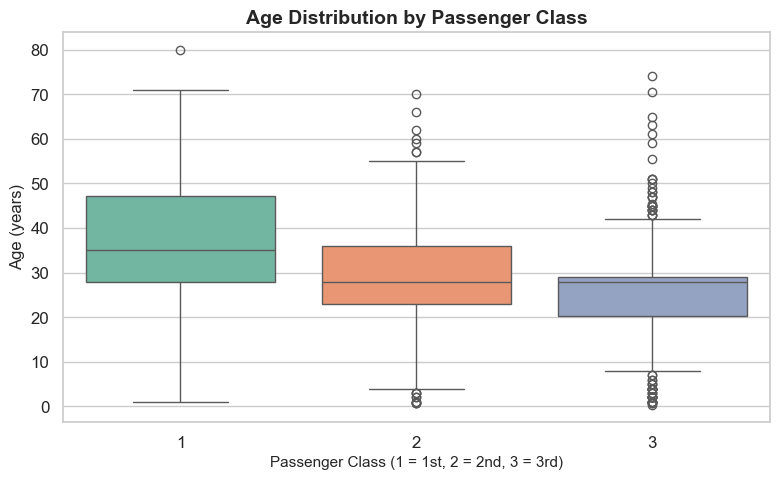

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2', ax=ax)

ax.set_title('Age Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=11)
ax.set_ylabel('Age (years)', fontsize=12)

plt.tight_layout()
plt.show()

---

## Visualization 15 — Violin Plot: Age by Gender and Survival

A **violin plot** combines a box plot with a KDE curve, showing the full distribution shape. Here we split the plot by **gender** and further color by **survival status**, revealing how age distributions differed for survivors and non-survivors within each gender.

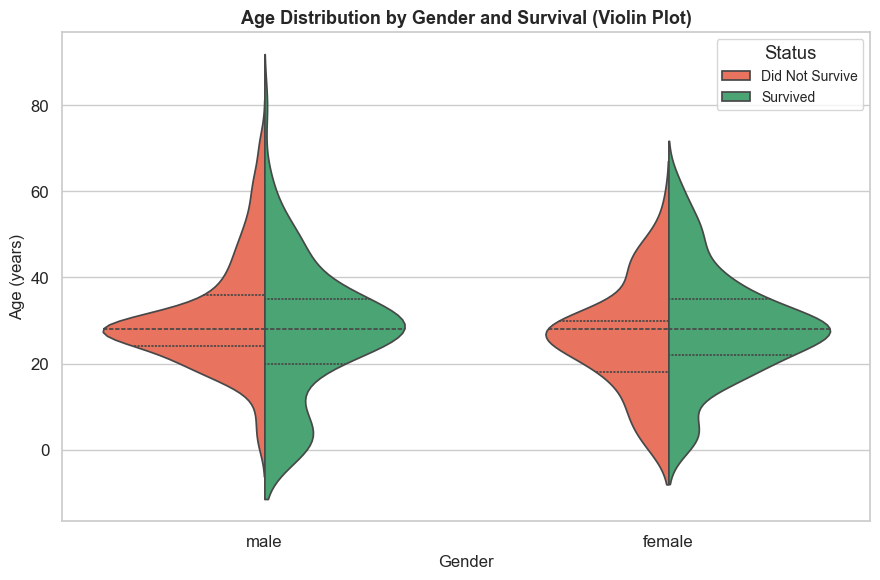

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.violinplot(data=df, x='Sex', y='Age', hue='Survived_Label',
               split=True,
               palette={'Did Not Survive': 'tomato', 'Survived': 'mediumseagreen'},
               inner='quart', ax=ax)

ax.set_title('Age Distribution by Gender and Survival (Violin Plot)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
ax.legend(title='Status', fontsize=10)

plt.tight_layout()
plt.show()

## Conclusion

- Women survived far more than men — the "women and children first" rule was clearly followed
- 1st class passengers had the highest survival rate, 3rd class the lowest
- Passengers who paid higher fares were more likely to survive
- Most passengers were aged 20–40; children had better survival chances
- Fare and Pclass are the strongest predictors of survival

> **Survival on the Titanic was not random — gender, class, and fare were the key deciding factors.**

## Key Insights

- **Gender** was the single most important survival factor — females had ~74% survival rate vs ~19% for males
- **Passenger Class** directly reflected lifeboat access — 1st class lifeboats were on upper decks
- **Fare** and **Pclass** are strongly correlated — wealthier passengers paid more and survived more
- **Children** had priority in evacuation, giving them higher survival chances
- **3rd class males** had the lowest survival rate of any group
- **Family size** (SibSp + Parch) shows that passengers mostly traveled in family groups
- Seaborn visualizations made these patterns easy to identify and compare